# MAE3405 Assignment 1 - 2026

Dr Daniel Duke

Department of Mechanical & Aerospace Engineering

Monash University

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


## Step 1. Functions to calculate engine Power and BSFC

Assuming an Air-Standard cycle

In [2]:
def standardAtmosphereDensity(z_km):
    r = np.roots((6.10767, -2.20467e1, 1.79402e1-z_km))
    r = r[(r>0)&(r<1.3)]
    return np.min(r)

def standardAtmosphereTemp(z_km):
    # Includes tropopause, good up to 22.5 km (same as MAE3405 notes)
    T = -6.5*z_km + 2.8815e2
    T[z_km>=11.] = 216.65
    T[z_km>20.] = 1.*z_km[z_km>20.] + 1.9665e2 
    return T

In [3]:
def boundEfficiency(x): # for scalars
    if x<0: return 0
    elif x>1: return 1
    else: return x  

def fuelAirOttoCycle(T1,rho1,RPM,bore=0.1,stroke=0.1,ncyl=4,compressionRatio=8,\
                     LHV=43.7e3,AFstoich=14.7,equivalenceRatio=1.,combustionEfficiency=1.,\
                    mechanicalEfficiency=.95,fourStroke=True,volumetricEfficiency=1.):
    
    # Calculate the performance of a Fuel-air Otto Cycle.
    # Assumed fuel and air already mixed at intake (non DI)
    # No chemistry calcualtion - provide LHV, AFs & combustion efficiency as inputs.
    # No super/turbocharging calculation - provide T1 and p1 as inputs.
    
    # Temps in Kelvin.
    # Bore, stroke in m
    # LHV in kJ/kg_f

    # Apply some sanity checks to inputs
    mechanicalEfficiency = boundEfficiency(mechanicalEfficiency)
    volumetricEfficiency = boundEfficiency(volumetricEfficiency)
    combustionEfficiency = boundEfficiency(combustionEfficiency)
    assert all((T1>0, rho1>0, bore>0, stroke>0, ncyl>0, compressionRatio>0))
    assert all((LHV>0, AFstoich>0, equivalenceRatio>0))
    
    
    # Thermo constants for Fuel-Air Cycle from notes
    gamma_r = 1.327
    gamma_p = 1.259
    cv_r = 0.8392 #kJ/kg.K
    cv_p = 1.143 #kJ/kg.K

    # Fuel-air cycle
    AF = AFstoich/equivalenceRatio
    Qh = combustionEfficiency * LHV / (1+AF)

    T2 = T1*(compressionRatio)**(gamma_r-1) # isentropic compression
    T3 = (cv_r*(T2-298) + Qh)/cv_p + 298 # isochoric heating
    T4 = T3*(1/compressionRatio)**(gamma_p-1) # isentropic expansion

    eta_th = (cv_p*(T3-T4) - cv_r*(T2-T1))/(cv_p*(T3-298)-cv_r*(T2-298))*combustionEfficiency
    eta_bth = mechanicalEfficiency * eta_th

    # Engine volume and power
    sweptVol = ncyl*stroke*(bore**2)*np.pi*0.25 # m^3
    sweptRate = sweptVol * (RPM/60.) # m^3/s
    if fourStroke: sweptRate /= 2.
    inducedAirRate = rho1*sweptRate*volumetricEfficiency # kg/s
    brakePower = (LHV*1e3/AF)*inducedAirRate*eta_bth # Watts

    # Fuel consumption
    fuelRate = inducedAirRate/AF
    
    # Performance
    BMEP = brakePower/sweptRate/1e6 # MPa
    BSFC = fuelRate / brakePower * 1e3 * 3600 #kg/kW.hr

    return eta_bth, brakePower, BMEP, BSFC
    

In [4]:
def fuelAirDieselCycle(T1,rho1,RPM,bore=0.1,stroke=0.1,ncyl=4,compressionRatio=15,\
                     LHV=42.5e3,AFstoich=14.5,equivalenceRatio=1.,combustionEfficiency=1.,\
                    mechanicalEfficiency=.95,fourStroke=True,volumetricEfficiency=1.,\
                      cutoffRatio=2.6):
    
    # Calculate the performance of a Fuel-air Diesel Cycle.
    # Assumed fuel and air already mixed at intake (non DI)
    # No chemistry calcualtion - provide LHV, AFs & combustion efficiency as inputs.
    # No super/turbocharging calculation - provide T1 and p1 as inputs.
    
    # Temps in Kelvin.
    # Bore, stroke in m
    # LHV in kJ/kg_f

    # Apply some sanity checks to inputs
    mechanicalEfficiency = boundEfficiency(mechanicalEfficiency)
    volumetricEfficiency = boundEfficiency(volumetricEfficiency)
    combustionEfficiency = boundEfficiency(combustionEfficiency)
    assert all((T1>0, rho1>0, bore>0, stroke>0, ncyl>0, compressionRatio>0))
    assert all((LHV>0, AFstoich>0, equivalenceRatio>0))
    
    
    # Thermo constants for Fuel-Air Cycle from notes
    gamma_r = 1.38
    gamma_p = 1.25
    R_r = 0.266 #kJ/kg.K
    R_p = 0.275 #kJ/kg.K
    cp_r = (gamma_r*R_r)/(gamma_r-1) #kJ/kg.K
    cp_p = (gamma_p*R_p)/(gamma_p-1) #kJ/kg.K
    cv_r = (R_r)/(gamma_r-1) #kJ/kg.K
    cv_p = (R_p)/(gamma_p-1) #kJ/kg.K
    
    # Fuel-air cycle
    AF = AFstoich/equivalenceRatio
    Qh = combustionEfficiency * LHV / (1+AF)

    p1 = rho1*R_r*T1*1e3 # Pa
    v1 = 1/rho1 # m3/kg
    
    p2 = p1*(compressionRatio)**(gamma_r)   # isentropic compression
    T2 = T1*(compressionRatio)**(gamma_r-1) # isentropic compression
    v2 = v1/compressionRatio                # isentropic compression
    
    v3 = v2*cutoffRatio                  # isobaric expansion
    w23 = p2*(v3-v2)*1e-3  #kJ/kg        # isobaric expansion
    T3 = (cp_r*(T2-298) + Qh - w23)/cp_p + 298 # isobaric heating
    p3 = R_p*T3/v3

    v4 = v1 # mass and volume back to same as state 1 if non-DI
    p4 = p3*(v3/v4)**gamma_p # note that expansion ratio ≠ compression ratio in Diesel
    T4 = T3*(v3/v4)**(gamma_p-1) # isentropic expansion
    
    Ql = cv_p*(T4-298)-cv_r*(T1-298)
    eta_th = (Qh-Ql)/Qh
    eta_bth = mechanicalEfficiency * eta_th

    # Engine volume and power
    sweptVol = ncyl*stroke*(bore**2)*np.pi*0.25 # m^3
    sweptRate = sweptVol * (RPM/60.) # m^3/s
    if fourStroke: sweptRate /= 2.
    inducedAirRate = rho1*sweptRate*volumetricEfficiency # kg/s
    brakePower = (LHV*1e3/AF)*inducedAirRate*eta_bth # Watts

    # Fuel consumption
    fuelRate = inducedAirRate/AF
    
    # Performance
    BMEP = brakePower/sweptRate/1e6 # MPa
    BSFC = fuelRate / brakePower * 1e3 * 3600 #kg/kW.hr

    return eta_bth, brakePower, BMEP, BSFC

## Step 2. Calculate aircraft performance in steady level flight

Given a particular weight, airspeed, propeller and aerodynamic properties - determine the thrust and power required to fly

In [5]:
from scipy.optimize import root

def propulsiveEfficiency_Froude(airspeed=100., propDiameter=2.0, shaftPower=100e3, rho=1.2):
    # Solve the Froude Theory equations for efficiency and thrust given power input
    
    # Return the efficiency and thrust produced by an ideal propeller
    A = 0.25*np.pi*propDiameter**2
    u = airspeed
    
    def fFroude(vars):
        w, thrust = vars # w is induced velocity m/s
        return [ thrust*(u+w) - shaftPower ,\
                 -2*w - u + np.sqrt(u**2 + 2*thrust/(rho*A)) ]

    # Use static thrust for initial guess
    guess_thrust = np.cbrt( shaftPower**2 * (2*rho*A) )
    guess_w = np.sqrt(guess_thrust/(2*rho*A))
    
    solveFroude = root(fFroude, [guess_w,guess_thrust])
    w, thrust = solveFroude.x
    propulsiveEfficiency=1/(1+w/u)

    return propulsiveEfficiency, thrust

Estimate the range and endurance of a propeller-driven aircraft

In [135]:
def minDragAirspeed(mass, rho, wingArea, dragPolar=(0.02,0.05)): 
    cD0, K = dragPolar # K = 1/(pi*AR*e)
    ustar = np.sqrt(2*mass*9.81/(rho*wingArea)) * (K/cD0)**0.25
    return ustar

def breguetProp(airspeed=50, mass_full=1e3, mass_empty=0.75e3, rho=1.2, dragPolar=(0.02,0.05),\
               propulsiveEfficiency=0.85, BSFC=0.2):
    # Solve range and endurance using the Breguet range equations for a power-producing engine
    # airspeed units m/s
    # mass units kg
    # density units kg/m3
    # bsfc units kg/kw.hr
    
    # Require lift to balance weight L=mg
    mass_avg = (mass_full + mass_empty)/2.
    c_L = 0.5*rho*(airspeed**2)/(mass_avg*9.81)
    c_D = dragPolar[0] + dragPolar[1]*c_L**2
    glideSlope = c_L/c_D
    
    # Check if c_L in valid range
    infiniteWingAoA = (180/np.pi)*c_L/np.pi # degrees
    if infiniteWingAoA > 12:
        raise RuntimError("stall")

    massRatio = mass_full/mass_empty
    bsfc_si = BSFC * 1e-3 / 3600 # convert kg/kW.hr to kg/Ws

    breguet = propulsiveEfficiency*np.log(massRatio)/(bsfc_si*9.81)
    Eprop = (glideSlope/airspeed)*breguet/3600 # hours
    
    L_DV_best_ratio = np.sqrt(3/4)*(1./3.)**-0.25
    c_L_minDrag = np.sqrt(dragPolar[0]/dragPolar[1])
    c_D_minDrag = 2*dragPolar[0]
    bestGlideSlope = (c_L_minDrag/c_D_minDrag)
    Eprop_max = L_DV_best_ratio*bestGlideSlope*breguet/3600 # hours


    Rprop = glideSlope*breguet/1000 # km
    Rprop_max = bestGlideSlope*breguet/1000 # km
    
    return Eprop, Eprop_max, Rprop, Rprop_max


In [136]:
def maxPossibleAirspeed(mass, rho, wingArea, dragPolar, thrustPower): 
    weight = 9.81*mass
    
    # Solve quartic equation to find best airspeed for a given thrust power [W]
    # a.u^4 + b.u + c == 0
    a = rho*wingArea*dragPolar[0]
    b = -2*thrustPower
    c = 4*dragPolar[1]*(weight**2)/(rho*wingArea)

    r = np.roots((a,0,0,b,c))
    realRoots = r[np.isreal(r)]
    if len(realRoots) < 1: return np.nan
    return np.real(np.nanmax(realRoots))
    

## Step 3. Solve for Engine as function of cruise altitude

(a)	Calculate and plot one engine’s brake power output (in kW) from sea level up to the service ceiling of 8 km.

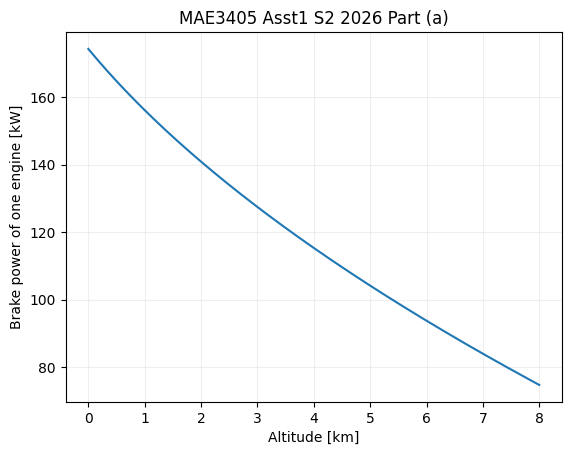

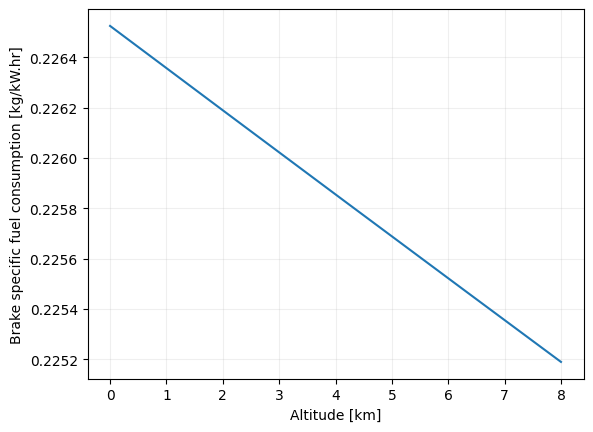

In [177]:
def brakePowerkW_fun(z_km):
    T1 = standardAtmosphereTemp(z_km)    
    output = np.empty(z_km.shape)
    bsfc = np.empty(z_km.shape)
    for i in range(len(z_km)):
        rho1 = standardAtmosphereDensity(z_km[i])

        eta_bth, brakePower, BMEP, BSFC = fuelAirOttoCycle(T1[i],rho1,\
                                                    2200,bore=5.125*0.0254,stroke=4.375*0.0254,ncyl=6,\
                                                    compressionRatio=7.30,LHV=43.7e3,AFstoich=14.7,\
                                                    equivalenceRatio=1.,combustionEfficiency=0.95,\
                                                    mechanicalEfficiency=.95,fourStroke=True,\
                                                    volumetricEfficiency=0.8)
        output[i] = brakePower/1e3
        bsfc[i] = BSFC
    return output, bsfc

z = np.linspace(0,8,200)
Wb, bsfc = brakePowerkW_fun(z)

fig=plt.figure()
plt.plot(z,Wb)
plt.grid(alpha=.2)
plt.xlabel('Altitude [km]');
plt.ylabel('Brake power of one engine [kW]')
plt.title('MAE3405 Asst1 S2 2026 Part (a)');

fig=plt.figure()
plt.plot(z,bsfc)
plt.grid(alpha=.2)
plt.xlabel('Altitude [km]');
plt.ylabel('Brake specific fuel consumption [kg/kW.hr]');
#plt.title('MAE3405 Asst1 S2 2026 Part (a)');

## Step 4. Determine the minimum-drag airspeed over the altitude range

Find range of altitudes where we have sufficient power to fly at the stated engine conditions

Text(0, 0.5, 'Min-drag airspeed [km/hr]')

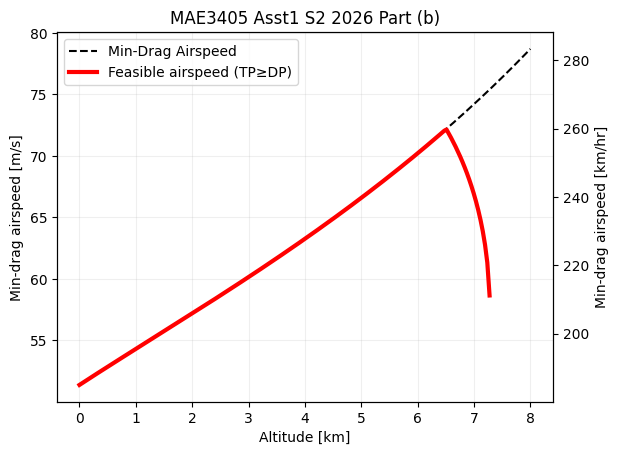

In [178]:
rho = standardAtmosphereDensity(0)
mtow = 2948.35
fuelVol = 919.86 #L
fuelMass = 0.7082 * fuelVol
mass = mtow-fuelMass/2.
wingArea = 21.3
dragPolar=(0.03,0.055)
eta_p=0.85
nEngines=2

# Find min-drag airspeed
rho1 = np.array( [ standardAtmosphereDensity(z_) for z_ in z ] )
ustar = np.array( [ minDragAirspeed(mass, rho_, wingArea, dragPolar=dragPolar) for rho_ in rho1 ] )

# Calculate drag force and power at min-drag conditions.
cD_minDrag = 2*dragPolar[0]
dragForce = 0.5*rho1*(ustar**2)*cD_minDrag*wingArea
dragPower_kW = 1e-3*dragForce*ustar

# Get thrust power actually available
thrustPower_kW = nEngines*Wb*eta_p

# Calculate how fast we could go if we used all available engine power.
max_airspeed = [ maxPossibleAirspeed(mass, rho1[i], wingArea, dragPolar, thrustPower_kW[i]*1e3) for i in range(len(rho1)) ]

# Optimum airspeed is the minimum of min-drag airspeed and max possible airspeed.
# We can only fly at min-drag airspeed if there is enough power to do so!
ustar_valid = np.min(np.vstack((ustar,max_airspeed)),axis=0)


fig=plt.figure()
plt.plot(z,ustar,label='Min-Drag Airspeed',ls='--',c='k')
plt.plot(z,ustar_valid,label='Feasible airspeed (TP≥DP)',lw=3,c='r')
plt.legend();
plt.grid(alpha=.2)
plt.xlabel('Altitude [km]');
plt.ylabel('Min-drag airspeed [m/s]')
plt.title('MAE3405 Asst1 S2 2026 Part (b)');
ylim = plt.gca().get_ylim()

plt.twinx();
plt.ylim(ylim[0]*3.6,ylim[1]*3.6)
plt.ylabel('Min-drag airspeed [km/hr]')

#plt.twinx();
#plt.plot(z,thrustPower_kW,ls='--',label='TP');
#plt.plot(z,dragPower_kW,ls='--',label='DP');
#plt.legend();
    

## Step 5. Make range and endurance calculations

Assume aircraft maintains a constant airspeed 

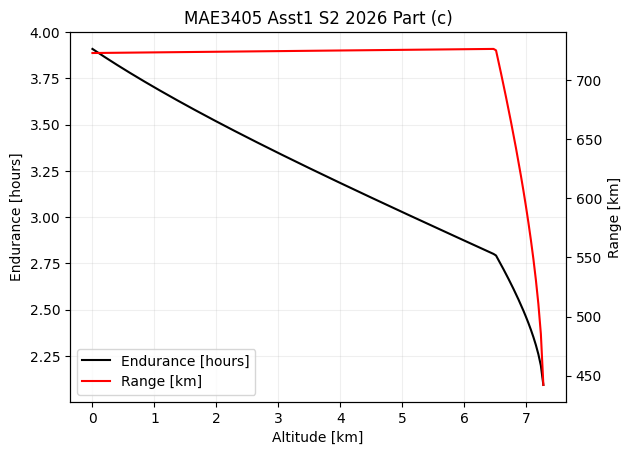

In [181]:
output=[]

for i in range(len(ustar)):
    Eprop, Eprop_max, Rprop, Rprop_max = breguetProp(airspeed=ustar_valid[i], mass_full=mtow,\
           mass_empty=mtow-fuelMass, rho=rho1[i], dragPolar=dragPolar,\
           propulsiveEfficiency=eta_p, BSFC=bsfc[i])
    output.append((Eprop,Rprop))

output=np.array(output)

fig=plt.figure()
p1,=plt.plot(z[~np.isnan(ustar_valid)],output[~np.isnan(ustar_valid),0],label='Endurance [hours]',c='k')
plt.plot(z[np.isnan(ustar_valid)],output[np.isnan(ustar_valid),0],label=None,ls='--',c='k')
plt.grid(alpha=.2)

plt.xlabel('Altitude [km]');
plt.ylabel('Endurance [hours]')
plt.title('MAE3405 Asst1 S2 2026 Part (c)');

plt.twinx()
p2,=plt.plot(z[~np.isnan(ustar_valid)],output[~np.isnan(ustar_valid),1],label='Range [km]',c='r')
plt.plot(z[np.isnan(ustar_valid)],output[np.isnan(ustar_valid),1],label=None,c='r',ls='--')
plt.ylabel('Range [km]')

plt.legend((p1,p2),[a.get_label() for a in (p1,p2)]);

In [176]:
maxE = np.nanmax(output[:,0])
maxE_z = z[np.where(output[:,0]==maxE)][0]

maxR = np.nanmax(output[:,1])
maxR_z = z[np.where(output[:,1]==maxR)][0]

print("Maximum endurance is %.1f hrs at z=%.2f km" % (maxE,maxE_z))
print("Maximum range is %.1f km at z=%.2f km" % (maxR,maxR_z))

Maximum endurance is 3.9 hrs at z=0.00 km
Maximum range is 726.8 km at z=5.11 km
